In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio as rio
from multiclean import clean_array

In [2]:
data_dir = Path().cwd() / "data"

In [3]:
land_use_sample_a_path = data_dir / "land use a.tif"
land_use_sample_b_path = data_dir / "land use b.tif"

In [4]:
array_a = rio.open(land_use_sample_a_path).read(1)
array_b = rio.open(land_use_sample_b_path).read(1)

In [25]:
array_a_cleaned = clean_array(array=array_a, smooth_edge_size=2, min_island_size=10)

In [26]:
array_a_cleaned.shape

(355, 330)

In [27]:
array_b_cleaned = clean_array(array=array_b, smooth_edge_size=1, min_island_size=10)

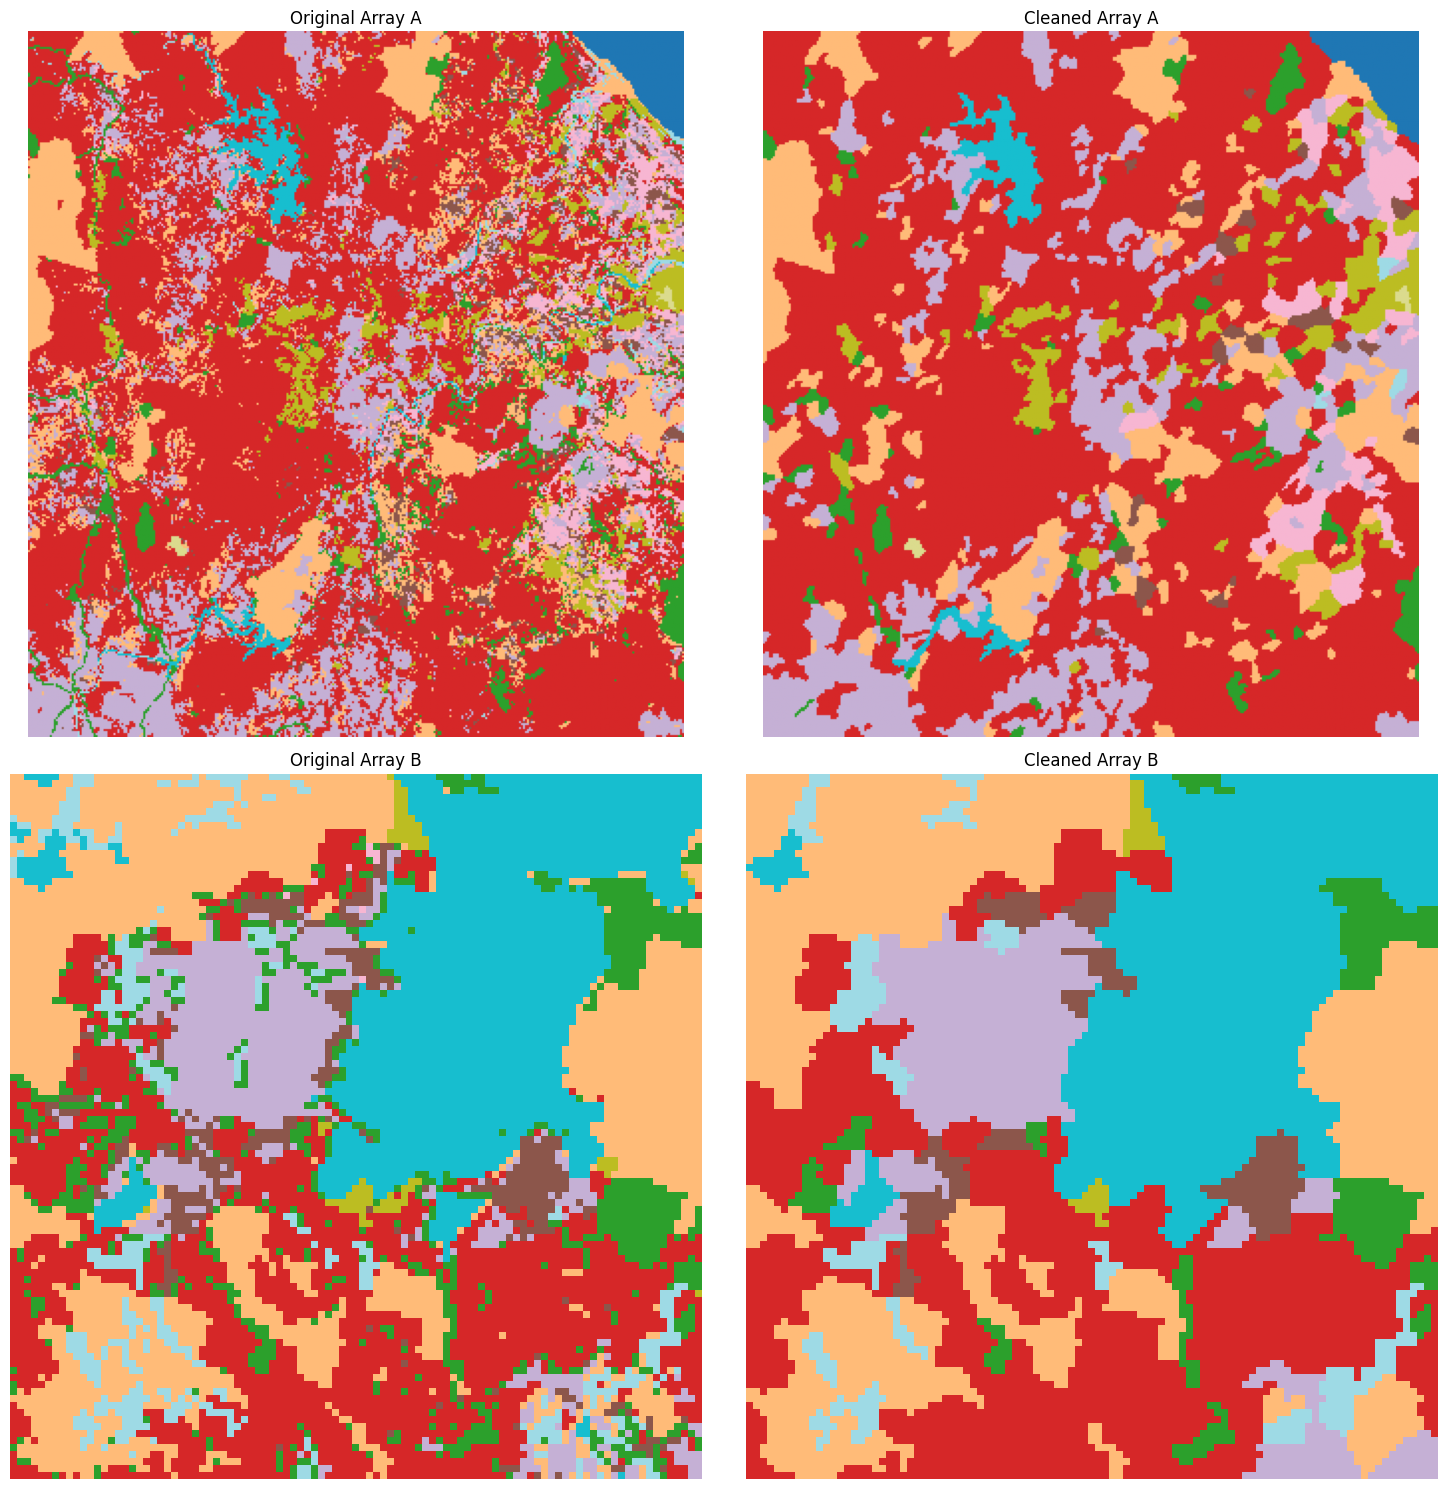

In [ ]:
# Find the global min and max values across all arrays
all_arrays = [array_a, array_a_cleaned, array_b, array_b_cleaned]
global_min = min(np.min(arr) for arr in all_arrays)
global_max = max(np.max(arr) for arr in all_arrays)

# Visualise inputs and outputs
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
axs[0, 0].imshow(array_a, cmap="tab20", vmin=global_min, vmax=global_max)
axs[0, 0].set_title("Original Array A")
axs[0, 1].imshow(array_a_cleaned, cmap="tab20", vmin=global_min, vmax=global_max)
axs[0, 1].set_title("Cleaned Array A")
axs[1, 0].imshow(array_b, cmap="tab20", vmin=global_min, vmax=global_max)
axs[1, 0].set_title("Original Array B")
axs[1, 1].imshow(array_b_cleaned, cmap="tab20", vmin=global_min, vmax=global_max)
axs[1, 1].set_title("Cleaned Array B")
for ax in axs.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [30]:
import cv2

In [36]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, 1))

In [37]:
kernel

array([[1]], dtype=uint8)